### TD Loss over Training

Training for 12000 episodes...
Episode 100/12000 | Score: 0 | Avg(100): 0.20 | Best: 2 | ε: 0.951
Episode 200/12000 | Score: 0 | Avg(100): 0.29 | Best: 2 | ε: 0.905
Episode 300/12000 | Score: 1 | Avg(100): 0.38 | Best: 2 | ε: 0.861
Episode 400/12000 | Score: 0 | Avg(100): 0.45 | Best: 3 | ε: 0.819
Episode 500/12000 | Score: 1 | Avg(100): 0.55 | Best: 3 | ε: 0.779
Episode 600/12000 | Score: 1 | Avg(100): 0.57 | Best: 3 | ε: 0.741
Episode 700/12000 | Score: 0 | Avg(100): 0.75 | Best: 4 | ε: 0.705
Episode 800/12000 | Score: 1 | Avg(100): 0.98 | Best: 5 | ε: 0.670
Episode 900/12000 | Score: 1 | Avg(100): 0.96 | Best: 5 | ε: 0.638
Episode 1000/12000 | Score: 2 | Avg(100): 0.98 | Best: 5 | ε: 0.606
Episode 1100/12000 | Score: 1 | Avg(100): 0.97 | Best: 5 | ε: 0.577
Episode 1200/12000 | Score: 3 | Avg(100): 1.14 | Best: 7 | ε: 0.549
Episode 1300/12000 | Score: 1 | Avg(100): 1.22 | Best: 7 | ε: 0.522
Episode 1400/12000 | Score: 0 | Avg(100): 1.45 | Best: 7 | ε: 0.496
Episode 1500/12000 | Score

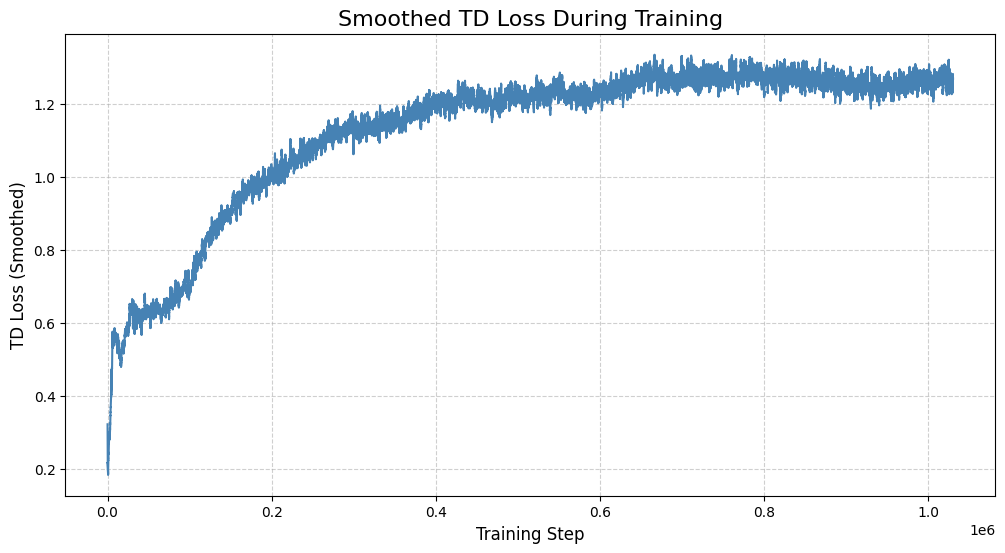

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

# Set the backend for inline plotting in Jupyter
%matplotlib inline

# Configuration
GRID_SIZE = 10

# --- Classes from your script (SnakeGame, DQN, DQNAgent) ---
# (No changes needed in these classes)

class SnakeGame:
    def __init__(self, grid_size=GRID_SIZE):
        self.grid_size = grid_size
        self.reset()

    def reset(self):
        center = self.grid_size // 2
        self.snake = [(center, center), (center, center - 1), (center, center - 2)]
        self.direction = (0, 1)
        self.food = self._place_food()
        self.score = 0
        self.steps_without_food = 0
        self.done = False
        self.prev_distance = self._get_distance_to_food()
        return self.get_state()

    def _place_food(self):
        while True:
            food = (random.randint(0, self.grid_size - 1),
                    random.randint(0, self.grid_size - 1))
            if food not in self.snake:
                return food

    def _get_distance_to_food(self):
        head = self.snake[0]
        return abs(head[0] - self.food[0]) + abs(head[1] - self.food[1])

    def get_state(self):
        head = self.snake[0]
        danger_up = self._is_collision((head[0] - 1, head[1]))
        danger_down = self._is_collision((head[0] + 1, head[1]))
        danger_left = self._is_collision((head[0], head[1] - 1))
        danger_right = self._is_collision((head[0], head[1] + 1))
        danger_up_left = self._is_collision((head[0] - 1, head[1] - 1))
        danger_up_right = self._is_collision((head[0] - 1, head[1] + 1))
        danger_down_left = self._is_collision((head[0] + 1, head[1] - 1))
        danger_down_right = self._is_collision((head[0] + 1, head[1] + 1))
        dir_up = (self.direction == (-1, 0))
        dir_down = (self.direction == (1, 0))
        dir_left = (self.direction == (0, -1))
        dir_right = (self.direction == (0, 1))
        food_up = (self.food[0] < head[0])
        food_down = (self.food[0] > head[0])
        food_left = (self.food[1] < head[1])
        food_right = (self.food[1] > head[1])
        state = [danger_up, danger_down, danger_left, danger_right,
                 danger_up_left, danger_up_right, danger_down_left, danger_down_right,
                 dir_up, dir_down, dir_left, dir_right,
                 food_up, food_down, food_left, food_right]
        return np.array(state, dtype=float)

    def _turn_right(self, direction):
        return (direction[1], -direction[0])

    def _turn_left(self, direction):
        return (-direction[1], direction[0])

    def _is_collision(self, pos):
        row, col = pos
        if row < 0 or row >= self.grid_size or col < 0 or col >= self.grid_size:
            return True
        if pos in self.snake:
            return True
        return False

    def step(self, action):
        if action == 1:
            self.direction = self._turn_right(self.direction)
        elif action == 2:
            self.direction = self._turn_left(self.direction)
        head = self.snake[0]
        new_head = (head[0] + self.direction[0], head[1] + self.direction[1])
        if self._is_collision(new_head):
            self.done = True
            return self.get_state(), -10, True
        self.snake.insert(0, new_head)
        current_distance = self._get_distance_to_food()
        reward = 0
        if new_head == self.food:
            self.score += 1
            reward = 10
            self.food = self._place_food()
            self.steps_without_food = 0
            self.prev_distance = self._get_distance_to_food()
        else:
            self.snake.pop()
            if current_distance < self.prev_distance:
                reward = 1
            else:
                reward = -1
            self.prev_distance = current_distance
            self.steps_without_food += 1
        if self.steps_without_food > 100 * self.grid_size:
            self.done = True
            reward = -10
        return self.get_state(), reward, self.done

class DQN(nn.Module):
    def __init__(self, input_size=16, hidden_size=256, output_size=3):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc4 = nn.Linear(hidden_size // 2, output_size)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

class DQNAgent:
    def __init__(self, state_size=16, action_size=3, learning_rate=0.0005,
                 gamma=0.95, epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=100000)
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.model = DQN(state_size, 256, action_size)
        self.target_model = DQN(state_size, 256, action_size)
        self.update_target_network()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        self.criterion = nn.SmoothL1Loss()
        self.update_counter = 0

    def update_target_network(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return torch.argmax(q_values).item()

    def replay(self, batch_size=128):
        if len(self.memory) < batch_size:
            return None
        minibatch = random.sample(self.memory, batch_size)
        states = torch.FloatTensor([x[0] for x in minibatch])
        actions = torch.LongTensor([x[1] for x in minibatch])
        rewards = torch.FloatTensor([x[2] for x in minibatch])
        next_states = torch.FloatTensor([x[3] for x in minibatch])
        dones = torch.FloatTensor([x[4] for x in minibatch])
        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze()
        with torch.no_grad():
            next_actions = self.model(next_states).max(1)[1]
            next_q = self.target_model(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * self.gamma * next_q
        loss = self.criterion(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()
        self.update_counter += 1
        if self.update_counter % 500 == 0:
            self.update_target_network()
        return loss # Return the loss tensor

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# --- MODIFIED Training Function to Capture Loss ---
def train_and_plot(training_env, training_agent, episodes=12000):
    scores = []
    td_losses = [] # <-- New list to store losses
    best_score = 0
    moving_avg_window = 100

    print(f"Training for {episodes} episodes...")

    for episode in range(episodes):
        state = training_env.reset()

        while not training_env.done:
            action = training_agent.act(state)
            next_state, reward, done = training_env.step(action)
            training_agent.remember(state, action, reward, next_state, done)

            # Capture the loss from the replay step
            loss = training_agent.replay()
            if loss is not None:
                # .item() gets the scalar value from the PyTorch tensor
                td_losses.append(loss.item())

            state = next_state

        training_agent.decay_epsilon()
        scores.append(training_env.score)

        if training_env.score > best_score:
            best_score = training_env.score

        if (episode + 1) % 100 == 0:
            avg_score = np.mean(scores[-moving_avg_window:])
            print(f"Episode {episode + 1}/{episodes} | "
                  f"Score: {training_env.score} | "
                  f"Avg({moving_avg_window}): {avg_score:.2f} | "
                  f"Best: {best_score} | "
                  f"ε: {training_agent.epsilon:.3f}")

    print(f"\nTraining complete!")

    # --- PLOTTING THE TD LOSS ---

    # Use a moving average to smooth the loss curve and see the trend
    window_size = 500
    if len(td_losses) > window_size:
        td_losses_smooth = np.convolve(td_losses, np.ones(window_size)/window_size, mode='valid')
    else:
        td_losses_smooth = td_losses # Not enough data to smooth

    plt.figure(figsize=(12, 6))
    plt.plot(td_losses_smooth, color='steelblue')
    plt.title('Smoothed TD Loss During Training', fontsize=16)
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('TD Loss (Smoothed)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


# --- Main Execution Block ---
env = SnakeGame(grid_size=GRID_SIZE)
agent = DQNAgent()

# Run the training and plotting function
# NOTE: 5000 episodes is a moderate run. For better results, you might
# run 20,000 or more, but it will take longer.
train_and_plot(env, agent, episodes=12000)